# SAE 2.02 - Exploitation algorithmique d'un problème
BARSALI Ilyas BOIN Anna RUIZ Enrique ZOPPI Nicolas

Groupe 4 équipe 4

# Partie 1 : PageRank - version itérative, premier exemple

In [35]:
from numpy.random import randint 
import numpy as np
from math import sqrt
import matplotlib.pyplot as plt
import networkx as nx

#On définit d'abord la matrice de la partie 1
A = np.array([
 [0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0],
 [1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0],
 [1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
 [1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
 [1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
 [0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0],
 [1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0],
 [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0],
 [0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0],
 [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1],
 [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1],
 [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0],
 [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0],
 [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0]],dtype = float) 


In [36]:
#Renvoie la norme qui est egal a la racine de la somme des valeurs du vecteur au carré
def norme(X) : 
    return np.sqrt(np.sum(X**2))

#On retourne une matrice qui a des valeurs aléatoires et qui fait la taille de la matrice utilisée en paramètre dans puissanceItérée()
def creeMatriceAleatoire (i): 
    return np.random.rand(i); 

#L'algorithme du cours qui va nous permettre d'obtenir le tableau des scores
def puissanceIteree (A,e,Xo,incr) : 
    Xn = Xo.copy()
    XnOld = np.zeros(len(A))
    #Pour complètement implémenter l'algorithme, on doit séparer le cas si la matrice est stochastique ou non,mais on utilisera ici seulement le cas ou la matrice est stochastique
    if (estStochastique(A)) :
        while (norme(Xn - XnOld) > e) :
            XnOld = Xn.copy()
            AXn = A.dot(Xn)
            Xn = AXn.copy() 
    else :
        while (norme(Xn - XnOld) > e) :
            XnOld = Xn.copy()
            AXn = A.dot(Xn)
            Xn = AXn / norme(AXn)
    return (creerClassement(Xn,incr))

def puissanceItereeSansClassement (A,e,Xo) : #On utilise cette fonction quand on souhaite récupérer les résultats de la puissance itérée sans avoir recours au classement                                              #de la puissance itérée dans classer les pages
    Xn = Xo.copy()                           
    XnOld = np.zeros(len(A))
    if (estStochastique(A)) :
        while (norme(Xn - XnOld) > e) :
            XnOld = Xn.copy()
            AXn = A.dot(Xn)
            Xn = AXn.copy()
    else :
        while (norme(Xn - XnOld) > e) :
            XnOld = Xn.copy()
            AXn = A.dot(Xn)
            Xn = AXn / norme(AXn)
    return Xn

#Créé le classement sous la forme (numéro de la page,score) grâce à un tableau de tuples
def creerClassement(Xn,i) : 
    T = []
    for j in range (i,len(Xn) + i) :
        T.append((j,Xn[j - i]))
    return sorted(T, key= lambda x : x[1],reverse = True)

#Créé la version stochastique de la matrice en paramètre (primordial pour cette SAE)
def stochastique(A) : 
    M = A.copy()
    for i in range (len(A)):
        temp = 0
        for j in range (len(A)) :
            if (A[j][i] == 1.0) :
                temp += 1
        for k in range (len(A)) :
            if (A[k][i] == 1.0) :
                M[k][i] /= temp
    return M

#Renvoie si la matrice en paramètre est stochastique ou non
def estStochastique(A) : 
    for i in range (A.shape[0]):
        temp = 0
        for j in range (A.shape[0]) :
            temp += A[j][i]
        if (temp != 1.0):
            return False
    return True

#Retourne la transposée de la matrice, ici elle va servir à transformer nos matrices à la base qui sont des matrices du web En matrice de Page Rank, pouvant alors être étudiée
def transposee(A) : 
    return A.T     

#Renvoie la norme de la différence des deux vecteurs, servant à se retouver avec une seule valeur à étudier pour étudier les comparaisons
def solutionEquation(V,W) : 
    return norme(V - W)

#Vérifie si la matrice trouvée résout l'équation r = Q*r
def verification(Q,e) : 
    # r est notre vecteur retourné dans l'algorithme ci-dessous
    r = puissanceItereeSansClassement(Q,e,Xo)
    #R va nous afficher l'écart (sensé tendre vers le nul) entre r et Q*r
    R = solutionEquation(r, Q.dot(r))
    #ici, 1e-5 est la marge d'erreur
    if (R > 1e-5):     
        return "le vecteur retourné n'est pas solution de l'équation : r = Qr", R
    else : 
        return "le vecteur retourné est solution de l'équation : la norme de r = Qr = ", R

Xo = creeMatriceAleatoire(len(A))

Q = (stochastique(transposee(A)))
e = 10**(-10)
print ("Vecteur de score obtenu :\n\n",puissanceIteree (Q,e,Xo,1),"\n\nLe classement est sous la forme (numero de la page,score)\n")
print (verification(Q,e))

Vecteur de score obtenu :

 [(6, 1.0267244275037757), (10, 0.8556036902356703), (1, 0.8556036889372898), (8, 0.6844829516691837), (11, 0.34224147613648936), (12, 0.34224147613648936), (13, 0.34224147613648936), (14, 0.34224147613648936), (7, 0.34224147583459186), (9, 0.34224147583459186), (2, 0.34224147553269474), (3, 0.34224147553269474), (4, 0.34224147553269474), (5, 0.34224147553269474)] 

Le classement est sous la forme (numero de la page,score)

("le vecteur retourné est solution de l'équation : la norme de r = Qr = ", 8.767440202970796e-11)


## Partie 2 : PageRank - version itérative, deuxième exemple

In [37]:
#B est le graphe d'ordre 5 de la partie 2.
B = np.array([
 [0, 0, 0, 0, 0],
 [1, 0, 0, 0, 0],
 [1, 0, 0, 1, 0],
 [1, 1, 0, 0, 0],
 [1, 1, 0, 0, 0]], dtype = float)

Q = (transposee(B))

Xo = creeMatriceAleatoire(len(B))

print(Q)
print('\n')
print(puissanceIteree(Q, e,Xo,1))

[[0. 1. 1. 1. 1.]
 [0. 0. 0. 1. 1.]
 [0. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 0.]]


[(1, nan), (2, nan), (3, nan), (4, nan), (5, nan)]


/tmp/ipykernel_109810/1140911327.py:23: RuntimeWarning: invalid value encountered in divide
  Xn = AXn / norme(AXn)


In [38]:
#Question 2

#transforme la matrice en paramètre en matrice de transition, parfait quand nous nous retrouvons avec un graphe contenant un puit (une ligne avec que des 0 dans une matrice du web)
def matriceTransition(A,B,a) :     
    M = np.zeros((len(A),len(A)))  
    for i in range (len(A)):
        for j in range (len(A)) :
            if (sommeTableau(j,A) != 0):    
                M[i][j] = a*B[i][j] + (1-a)/len(A)
            else:
                M[i][j] = 1/len(A)
    return M       

#renvoie la somme des valeurs de la colonne j en paramètre
def sommeTableau(j,A) : 
    temp = 0
    for i in range (A.shape[0]):
        temp += A[i][j]
    return (temp)

a = 0.85
Xo = creeMatriceAleatoire(len(B))
P = matriceTransition(transposee(B),stochastique(transposee(B)),a)
print (P,"\n")
print (puissanceIteree(P,e,Xo,1),"\n")
print(verification(P,e))

[[0.2   0.88  0.455 0.455 0.455]
 [0.2   0.03  0.03  0.455 0.455]
 [0.2   0.03  0.03  0.03  0.03 ]
 [0.2   0.03  0.455 0.03  0.03 ]
 [0.2   0.03  0.03  0.03  0.03 ]] 

[(1, 1.2682246644229687), (2, 0.6158537563225323), (4, 0.43217807461876134), (3, 0.3032828593718929), (5, 0.3032828593718929)] 

("le vecteur retourné est solution de l'équation : la norme de r = Qr = ", 1.279982100734581e-11)


## Partie 3 : PageRank - version itérative, analyse des paramètres

In [5]:
#Question 1

#renvoie seulement le résultat de r - Qr
def equation(Q,e) : 
    r = puissanceItereeSansClassement(Q,e,Xo)
    return solutionEquation(r, Q.dot(r))

Xo = creeMatriceAleatoire(len(A))

Q = (stochastique(transposee(A)))

tab = []

e = 1
E = equation (Q,e)
print("e = ", e, " : ",E,"\n")
e = 0.1
E = equation (Q,e)
print("e = ", e, " : ",E,"\n")
tab.append(E)
e = 1e-2
E = equation (Q,e)
print("e = ", e, " : ",E,"\n")
tab.append(E)
e= 1e-4
E = equation (Q,e)
print("e = ", e, " : ",E,"\n")
tab.append(E)
e = 1e-6
E = equation (Q,e)
print("e = ", e, " : ",E,"\n")
tab.append(E)
e = 1e-8
E = equation (Q,e)
print("e = ", e, " : ",E,"\n")
tab.append(E)
e = 1e-10
E = equation (Q,e)
print("e = ", e, " : ",E,"\n")
tab.append(E)
e = 1e-14
E = equation (Q,e)
print("e = ", e, " : ",E,"\n")
tab.append(E)
e = 1e-18
E = equation (Q,e)
print("e = ", e, " : ",E,"\n")
tab.append(E)


e =  1  :  0.5564235302476511 

e =  0.1  :  0.03476272569896374 

e =  0.01  :  0.00828736338981836 

e =  0.0001  :  8.963423194181425e-05 

e =  1e-06  :  8.661237976249021e-07 

e =  1e-08  :  8.99847173203154e-09 

e =  1e-10  :  8.695105710446638e-11 

e =  1e-14  :  8.662585850030506e-15 

e =  1e-18  :  0.0 



In [10]:
#Question 2

#on va ajouter des pages supplémentaires par rapport au nombre de hubs et d'autorités voulu

    #ajout de d'1 hub pointé par aucune page 

H1 = np.array([
     [0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0],
     [1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
     [1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
     [1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
     [1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
     [0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0],
     [1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0],
     [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0],
     [0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0],
     [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0],
     [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0],
     [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0],
     [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0],
     [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0],
     [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0]]
         ,dtype=float)

    #ajout de 2 hubs pointés par aucune page 
    
H2 = np.array([
     [0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
     [1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
     [1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
     [1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
     [1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
     [0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0],
     [1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0],
     [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
     [0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0],
     [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0],
     [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0],
     [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0],
     [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0],
     [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0],
     [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0],
     [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0]]
         ,dtype = float)

    #ajout de 2 hubs pointés par aucune page, mais ne pointant pas 8

H3 = np.array([
     [0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
     [1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
     [1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
     [1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
     [1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
     [0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0],
     [1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0],
     [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
     [0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0],
     [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0],
     [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0],
     [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0],
     [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0],
     [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0],
     [1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0],
     [1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0]]
         ,dtype = float)

    #ajout d'une autoritée ne pointant aucune page 

A1 = np.array([
     [0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1],
     [1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1],
     [1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1],
     [1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1],
     [1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1],
     [0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1],
     [1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1],
     [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1],
     [0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1],
     [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1],
     [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1],
     [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1],
     [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1],
     [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1],
     [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]]
             ,dtype = float)
    
    #ajout de 2 autorités ne pointant aucune page 

A2 = np.array([
     [0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1],
     [1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1],
     [1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1],
     [1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1],
     [1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1],
     [0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1],
     [1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1],
     [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1],
     [0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1],
     [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1],
     [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1],
     [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1],
     [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1],
     [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1],
     [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
     [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]]
    
         ,dtype=float)
    
    
M = matriceTransition(transposee(A),stochastique(transposee(A)),a)
MH1 = matriceTransition(transposee(H1),stochastique(transposee(H1)),a)
MH2 = matriceTransition(transposee(H2),stochastique(transposee(H2)),a)
MH3 = matriceTransition(transposee(H3),stochastique(transposee(H3)),a)
MA1 = matriceTransition(transposee(A1),stochastique(transposee(A1)),a)
MA2 = matriceTransition(transposee(A2),stochastique(transposee(A2)),a)
    
Xo = creeMatriceAleatoire(14)
print("\nPour une matrice sans hub ni autorité :\n")
print (puissanceIteree (M,e,Xo,1))
    
Xo = creeMatriceAleatoire(15)
print("\nEn ajoutant un hub pointé par aucune page :\n")
print (puissanceIteree (MH1,e,Xo,1))
    
Xo = creeMatriceAleatoire(16)
print("\nEn ajoutant 2 hubs pointés par aucune page :\n")
print (puissanceIteree (MH2,e,Xo,1))

Xo = creeMatriceAleatoire(16)
print("\nEn ajoutant 2 hubs pointés par aucune page mais ne pointant pas 8:\n")
print (puissanceIteree (MH3,e,Xo,1))
    
Xo = creeMatriceAleatoire(15)
print("\nEn ajoutant une autorité ne pointant aucune page:\n")
print (puissanceIteree (MA1,e,Xo,1))
    
Xo = creeMatriceAleatoire(16)
print("\nEn ajoutant 2 autorités ne pointant aucune page:\n")
print (puissanceIteree (MA2,e,Xo,1))
print("\n")



Pour une matrice sans hub ni autorité :

[(6, 0.4368578146483824), (10, 0.43210734389001565), (1, 0.432107340626169), (8, 0.2975229322957022), (13, 0.1921827381730933), (11, 0.19218273817309328), (14, 0.19218273817309328), (12, 0.19218273817309325), (2, 0.19218273665528468), (3, 0.19218273665528468), (4, 0.19218273665528468), (5, 0.19218273665528465), (7, 0.16082320664632527), (9, 0.16082320664632527)]

En ajoutant un hub pointé par aucune page :

[(6, 0.43659160844168393), (1, 0.43184403259143533), (10, 0.4318440290620948), (8, 0.29734163199945496), (4, 0.19206562864950816), (2, 0.19206562864950813), (3, 0.19206562864950813), (5, 0.1920656286495081), (11, 0.19206562700823504), (13, 0.19206562700823504), (14, 0.192065627008235), (12, 0.19206562700823498), (7, 0.1607252064861928), (9, 0.1607252064861928), (15, 0.03490501755250534)]

En ajoutant 2 hubs pointés par aucune page :

[(6, 0.4363818347059717), (1, 0.4316365401190962), (10, 0.4316365363045137), (8, 0.297198765155631), (3, 0.19

In [39]:
#Question 3
#accroître le score de certaines pages

Xo = creeMatriceAleatoire(14)

print("\nLa matrice de base :\n")
print (puissanceIteree (M,e,Xo,1))


La matrice de base :

[(6, 0.43685781464837853), (1, 0.4321073424307994), (10, 0.43210734208538903), (8, 0.29752293229569854), (2, 0.19218273749450437), (3, 0.19218273749450437), (4, 0.19218273749450437), (5, 0.19218273749450437), (11, 0.19218273733387592), (12, 0.19218273733387592), (13, 0.19218273733387592), (14, 0.19218273733387592), (7, 0.16082320664632366), (9, 0.16082320664632366)]


In [40]:
print ("7 : ",puissanceIteree (M,e,Xo,1)[6],"\n9 : ",puissanceIteree (M,e,Xo,1)[8])

7 :  (4, 0.19218273749450437) 
9 :  (11, 0.19218273733387592)


In [47]:
T = np.array([
 [0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0],
 [1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0],
 [1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0],
 [1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0],
 [1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0],
 [0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0],
 [1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0],
 [0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0],
 [0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0],
 [0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1],
 [0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1],
 [0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0],
 [0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0],
 [0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0]],dtype = float)

MT = matriceTransition(transposee(T),stochastique(transposee(T)),a)

print ("Le classement après avoir ajouté des liens entrants à 7 et 9 :\n\n",puissanceIteree (MT,e,Xo,1))
print ("\n7 : ",puissanceIteree (MT,e,Xo,1)[1],"\n9 : ",puissanceIteree (MT,e,Xo,1)[0])

Le classement après avoir ajouté des liens entrants à 7 et 9 :

 [(9, 0.5551573704131132), (7, 0.555157370413113), (8, 0.40371917366483073), (1, 0.2541730155753316), (10, 0.25417301550113675), (6, 0.20668428206316578), (2, 0.07801056089084783), (3, 0.07801056089084782), (4, 0.07801056089084782), (5, 0.07801056089084782), (13, 0.07801056085203734), (11, 0.07801056085203732), (12, 0.07801056085203732), (14, 0.07801056085203732)]

7 :  (7, 0.555157370413113) 
9 :  (9, 0.5551573704131132)


In [52]:
#Question 4 
#faire varier le facteur d'amortissement pour analyser son influence.

Xo = creeMatriceAleatoire(len(A))

tab = []

a = 1
P = matriceTransition(transposee(A),stochastique(transposee(A)),a)
print ("\na = ",a," :\n",puissanceIteree(P.copy(),e,Xo,1))
resultat = puissanceItereeSansClassement(P,e,Xo)
tab.append(abs(np.std(resultat)))

a = 0.75
P = matriceTransition(transposee(A),stochastique(transposee(A)),a)
print ("\na = ",a," :\n",puissanceIteree(P.copy(),e,Xo,1))
resultat = puissanceItereeSansClassement(P,e,Xo)
tab.append(abs(np.std(resultat)))

a = 0.5
P = matriceTransition(transposee(A),stochastique(transposee(A)),a)
print ("\na = ",a," :\n",puissanceIteree(P.copy(),e,Xo,1))
resultat = puissanceItereeSansClassement(P,e,Xo)
tab.append(abs(np.std(resultat)))

a = 0.25
P = matriceTransition(transposee(A),stochastique(transposee(A)),a)
print ("\na = ",a," :\n",puissanceIteree(P.copy(),e,Xo,1))
resultat = puissanceItereeSansClassement(P,e,Xo)
tab.append(abs(np.std(resultat)))

a = 0.15
P = matriceTransition(transposee(A),stochastique(transposee(A)),a)
print ("\na = ",a," :\n",puissanceIteree(P.copy(),e,Xo,1))
resultat = puissanceItereeSansClassement(P,e,Xo)
tab.append(abs(np.std(resultat)))

a = 0.0
P = matriceTransition(transposee(A),stochastique(transposee(A)),a)
print ("\na = ",a," :\n",puissanceIteree(P.copy(),e,Xo,1),"\n")
resultat = puissanceItereeSansClassement(P,e,Xo)
tab.append(abs(np.std(resultat)))


a =  1  :
 [(6, 1.1905411214334594), (1, 0.992117607788888), (10, 0.992117594600211), (8, 0.7936940809556395), (2, 0.3968470435444297), (3, 0.3968470435444297), (4, 0.3968470435444297), (5, 0.3968470435444297), (7, 0.39684704047781977), (9, 0.39684704047781977), (11, 0.39684703741120997), (12, 0.39684703741120997), (13, 0.39684703741120997), (14, 0.39684703741120997)]

a =  0.75  :
 [(1, 0.42883071672491685), (10, 0.42883071435825776), (6, 0.4069267629888159), (8, 0.28757455929887016), (2, 0.20307397844351413), (3, 0.20307397844351413), (4, 0.20307397844351413), (5, 0.2030739784435141), (11, 0.20307397734293062), (12, 0.2030739773429306), (13, 0.2030739773429306), (14, 0.2030739773429306), (7, 0.16432831959931554), (9, 0.16432831959931554)]

a =  0.5  :
 [(1, 0.4012590721976122), (10, 0.4012590714117996), (6, 0.34966861972564045), (8, 0.28088135027314887), (3, 0.2254693833867625), (4, 0.22546938338676245), (2, 0.2254693833867624), (5, 0.2254693833867624), (12, 0.22546938302133088), (1

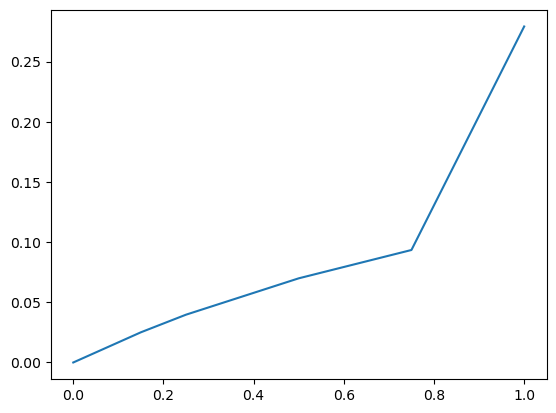

In [53]:
plt.plot([1,0.75,0.5,0.25,0.15,0],tab)
plt.show()

## Partie 4 : PageRank - version itérative, analyse des résultats.


Graphe de Youtube :



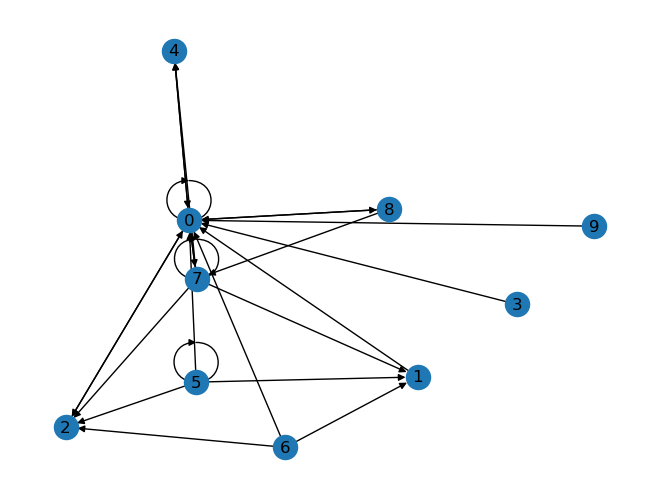


Vecteur des scores de Youtube : 
 [(0, 0.8644436177212983), (7, 0.3052323575386042), (2, 0.24672780681734832), (4, 0.22967396156565756), (8, 0.1777844607769578), (1, 0.09977239197601516), (5, 0.039147994838888464), (3, 0.03082904593562466), (6, 0.03082904593562466), (9, 0.03082904593562466)] 


Graphe de AMU :



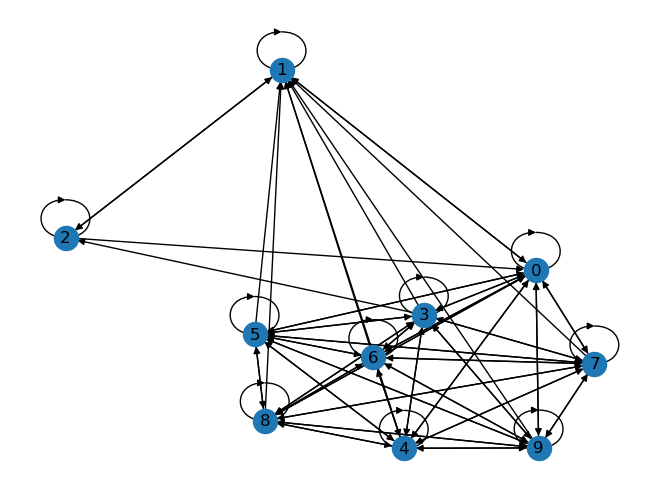

Vecteur des scores de AMU : 
 [(0, 0.47368253318789805), (1, 0.47368253318789805), (2, 0.28182700040103464), (3, 0.2596214984908241), (4, 0.2596214984908241), (5, 0.2596214984908241), (6, 0.2596214984908241), (7, 0.2596214984908241), (8, 0.2596214984908241), (9, 0.2596214984908241)] 


Graphe de Wikipédia :



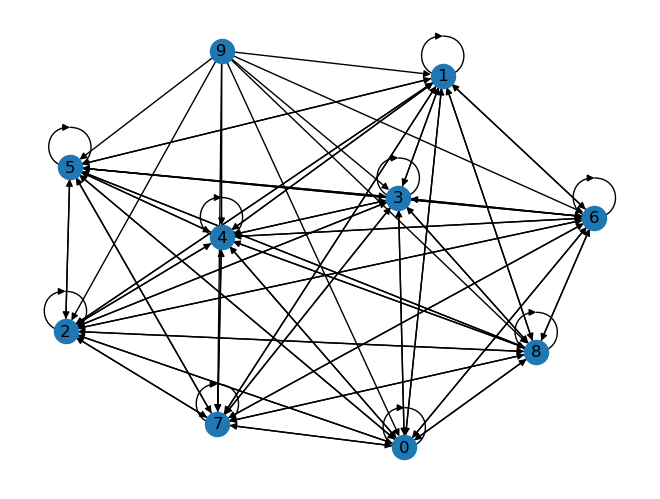

Vecteur des scores de Wikipédia : 
 [(0, 0.6429953835161264), (1, 0.6429953835161264), (2, 0.6429953835161264), (3, 0.6429953835161264), (4, 0.6429953835161264), (5, 0.6429953835161264), (6, 0.6429953835161264), (7, 0.6429953835161264), (8, 0.6429953835161264), (9, 0.08812627083723562)] 



In [12]:
#Question 1
#Premier site choisi : Youtube
Ytb = np.array([
    [1,0,1,0,1,0,0,1,1,0],   #0.86444362
    [1,0,0,0,0,0,0,0,0,0],   #0.09977239
    [1,0,0,0,0,0,0,0,0,0],   #0.24672781
    [1,0,0,0,0,0,0,0,0,0],   #0.03082905
    [1,0,0,0,0,0,0,0,0,0],   #0.22967396
    [1,1,1,0,0,1,0,0,0,0],   #0.03914799
    [1,1,1,0,0,0,0,0,0,0],   #0.03082905
    [1,1,1,0,1,0,0,1,0,0],   #0.30523236
    [1,0,0,0,0,0,0,1,0,0],   #0.17778446
    [1,0,0,0,0,0,0,0,0,0]],  #0.03082905
    dtype = float)

#Deuxième site choisi : AMU
Amu = np.array([
    [1,1,0,1,1,1,1,1,1,1],   #0.47368253
    [1,1,1,0,0,0,0,0,0,0],   #0.47368253
    [1,1,1,0,0,0,0,0,0,0],   #0.281827
    [1,1,1,1,1,1,1,1,1,1],   #0.2596215
    [1,1,0,1,1,1,1,1,1,1],   #0.2596215
    [1,1,0,1,1,1,1,1,1,1],   #0.2596215
    [1,1,0,1,1,1,1,1,1,1],   #0.2596215
    [1,1,0,1,1,1,1,1,1,1],   #0.2596215
    [1,1,0,1,1,1,1,1,1,1],   #0.2596215
    [1,1,0,1,1,1,1,1,1,1]],  #0.2596215
    dtype = float)

#Troisième site choisi : Wikipédia
Wiki = np.array([
    [1,1,1,1,1,1,1,1,1,0],   #0.53248714
    [1,1,1,1,1,1,1,1,1,0],   #0.53248714
    [1,1,1,1,1,1,1,1,1,0],   #0.53248714
    [1,1,1,1,1,1,1,1,1,0],   #0.53248714
    [1,1,1,1,1,1,1,1,1,0],   #0.53248714
    [1,1,1,1,1,1,1,1,1,0],   #0.53248714
    [1,1,1,1,1,1,1,1,1,0],   #0.53248714
    [1,1,1,1,1,1,1,1,1,0],   #0.53248714
    [1,1,1,1,1,1,1,1,1,0],   #0.53248714
    [1,1,1,1,1,1,1,1,1,0]],  #0.07298047
    dtype = float)

e = 10e-10
Xo = np.random.rand(10)  #car l'ordre de ces trois matrices est 10.

GYtb = nx.DiGraph(Ytb)
GAmu = nx.DiGraph(Amu)
GWiki = nx.DiGraph(Wiki)

nx.draw(GYtb, with_labels=True)
print ("\nGraphe de Youtube :\n")
plt.show()
TYtb = matriceTransition(transposee(Ytb), stochastique(transposee(Ytb)),a)
print("\nVecteur des scores de Youtube : \n",puissanceIteree(stochastique(TYtb), e,Xo,0),"\n")

nx.draw(GAmu, with_labels=True)
print ("\nGraphe de AMU :\n")
plt.show()
TAmu = matriceTransition(transposee(Amu), stochastique(transposee(Amu)),a)
print("Vecteur des scores de AMU : \n",puissanceIteree(stochastique(TAmu), e,Xo,0),"\n")

nx.draw(GWiki, with_labels=True)
print ("\nGraphe de Wikipédia :\n")
plt.show()
TWiki = matriceTransition(transposee(Wiki), stochastique(transposee(Wiki)),a)
print("Vecteur des scores de Wikipédia : \n",puissanceIteree(stochastique(TWiki), e,Xo,0),"\n")


Graphe du réseau :



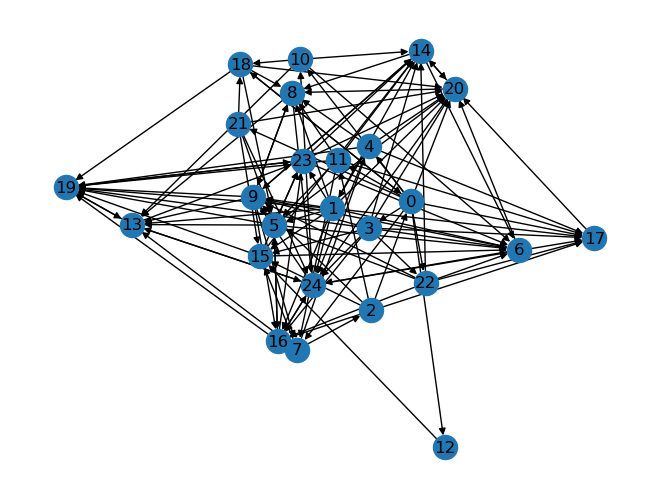

In [50]:
#Question 2 

RS = np.array([
    [0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0],
    [0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1],
    [1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1],
    [0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1],
    [0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1],
    [0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1],
    [0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0],
    [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0],
    [1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1],
    [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1],
    [0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0]],
    dtype = float)

GR = nx.DiGraph(RS.copy())
nx.draw(GR, with_labels=True)
print ("\nGraphe du réseau :\n")
plt.show()

In [51]:
#Algorithme pour le classement des comptes en fonction de leur nombre d'abonnés.

def classement(R) : 
    nbAbos = []
    for i in range (len(R)) :
        cpt = 0
        for j in range (len(R)) :
            if R[j][i] > 0 :
                cpt += 1.0
        nbAbos.append((i,cpt))
    nbAbos = sorted(nbAbos, key= lambda x : x[1],reverse = True)
    return nbAbos

print("\nClassement des comptes en fonction de leur nombre d'abonnés :\n(numéro du compte,nombre d'abonnés)\n")
print(classement(RS))
   
#Appliquer le PageRank
e = 10e-10

Xo = np.random.rand(len(RS))

TR = matriceTransition(transposee(RS), stochastique(transposee(RS)),a)

print("\nAlgorithme de la puissance itérée sur ce réseau :\n(numéro du compte,score)\n")
print(puissanceIteree(stochastique(TR), e,Xo,0),"\n")


Classement des comptes en fonction de leur nombre d'abonnés :
(numéro du compte,nombre d'abonnés)

[(19, 11.0), (20, 11.0), (6, 9.0), (14, 9.0), (24, 9.0), (13, 8.0), (17, 8.0), (5, 7.0), (8, 7.0), (9, 7.0), (16, 7.0), (15, 6.0), (23, 6.0), (7, 3.0), (18, 3.0), (0, 2.0), (4, 2.0), (10, 2.0), (11, 2.0), (22, 2.0), (1, 1.0), (2, 1.0), (3, 1.0), (12, 1.0), (21, 1.0)]

Algorithme de la puissance itérée sur ce réseau :
(numéro du compte,score)

[(0, 0.2), (1, 0.2), (2, 0.2), (3, 0.2), (4, 0.2), (5, 0.2), (6, 0.2), (7, 0.2), (8, 0.2), (9, 0.2), (10, 0.2), (11, 0.2), (12, 0.2), (13, 0.2), (14, 0.2), (15, 0.2), (16, 0.2), (17, 0.2), (18, 0.2), (19, 0.2), (20, 0.2), (21, 0.2), (22, 0.2), (23, 0.2), (24, 0.2)] 



## Partie 5 : PageRank - calcul direct des scores et comparaisons d’algorithmes